# Задание

1. Найти датасет на hugging face, который будет содержать в себе числовые данные (> 3 числовых признаков)

2. Очистить данные от выбросов методами, рассмотренными на практическом занятии

3. Произвести отбор признаков одним из способов, рассмотренных на лекционной части занятия

In [5]:
# Установка необходимых библиотек
import subprocess
import sys

packages = ['pandas', 'numpy', 'matplotlib', 'seaborn', 'scipy', 'datasets', 'scikit-learn']
for package in packages:
    try:
        __import__(package)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', package])

print("Все библиотеки установлены успешно!")

Все библиотеки установлены успешно!



[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from datasets import load_dataset
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

# Установим константы
SEED = 42
Z_THRESHOLD = 3
np.random.seed(SEED)

## Этап 1: Загрузка датасета

Используем датасет "kidney" с Hugging Face, который содержит 10 числовых признаков для диагностики заболевания почек.

In [7]:
# Загрузка датасета
dataset = load_dataset("mavihsrr/kidney-stone")
df = dataset["train"].to_pandas()

print(f"Форма датасета: {df.shape}")
print(f"\nПервые 5 строк:")
print(df.head())
print(f"\nИнформация о типах данных:")
print(df.dtypes)
print(f"\nОписательная статистика:")
print(df.describe())

Generating test split: 100%|██████████| 186/186 [00:00<00:00, 20306.11 examples/s]

Форма датасета: (241, 1)

Первые 5 строк:
                                                text
0  0 0.3248081841432225 0.6046875 0.0562659846547...
1  0 0.2672634271099744 0.646875 0.02813299232736...
2  0 0.25191815856777494 0.5859375 0.028132992327...
3  0 0.2966751918158568 0.5328125 0.0306905370843...
4  0 0.31074168797953966 0.5203125 0.028132992327...

Информация о типах данных:
text    object
dtype: object

Описательная статистика:
                                                     text
count                                                 241
unique                                                241
top     0 0.3248081841432225 0.6046875 0.0562659846547...
freq                                                    1


## Этап 2: Очистка данных от выбросов

Будем использовать два метода:
- **IQR метод** (Interquartile Range)
- **Z-Score метод**

In [8]:
# Функция для обнаружения выбросов методом IQR
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return (data[column] < lower_bound) | (data[column] > upper_bound)

# Функция для обнаружения выбросов методом Z-Score
def detect_outliers_zscore(data, column, threshold=Z_THRESHOLD):
    z_scores = np.abs(stats.zscore(data[column].dropna()))
    return np.abs(stats.zscore(data[column])) > threshold

# Подсчет выбросов для каждого признака
print("=== ОБНАРУЖЕНИЕ ВЫБРОСОВ ===\n")
print("Методом IQR:")
outliers_iqr = {}
for col in df.select_dtypes(include=[np.number]).columns:
    outliers = detect_outliers_iqr(df, col).sum()
    outliers_iqr[col] = outliers
    print(f"  {col}: {outliers} выбросов")

print("\nМетодом Z-Score:")
outliers_zscore = {}
for col in df.select_dtypes(include=[np.number]).columns:
    outliers = detect_outliers_zscore(df, col).sum()
    outliers_zscore[col] = outliers
    print(f"  {col}: {outliers} выбросов")

=== ОБНАРУЖЕНИЕ ВЫБРОСОВ ===

Методом IQR:

Методом Z-Score:


In [9]:
# Метод 1: Удаление выбросов (IQR)
print("\n=== МЕТОД 1: УДАЛЕНИЕ ВЫБРОСОВ (IQR) ===\n")

df_cleaned_removed = df.copy()
for col in df.select_dtypes(include=[np.number]).columns:
    Q1 = df_cleaned_removed[col].quantile(0.25)
    Q3 = df_cleaned_removed[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_cleaned_removed = df_cleaned_removed[
        (df_cleaned_removed[col] >= lower_bound) & 
        (df_cleaned_removed[col] <= upper_bound)
    ]

print(f"Размер датасета до удаления: {df.shape[0]}")
print(f"Размер датасета после удаления: {df_cleaned_removed.shape[0]}")
print(f"Удалено строк: {df.shape[0] - df_cleaned_removed.shape[0]}")
print(f"Процент оставшихся данных: {(df_cleaned_removed.shape[0] / df.shape[0] * 100):.2f}%")


=== МЕТОД 1: УДАЛЕНИЕ ВЫБРОСОВ (IQR) ===

Размер датасета до удаления: 241
Размер датасета после удаления: 241
Удалено строк: 0
Процент оставшихся данных: 100.00%


In [10]:
# Метод 2: Замена выбросов на граничные значения (IQR)
print("\n=== МЕТОД 2: ЗАМЕНА ВЫБРОСОВ НА ГРАНИЧНЫЕ ЗНАЧЕНИЯ (IQR) ===\n")

df_cleaned_replaced = df.copy()
for col in df.select_dtypes(include=[np.number]).columns:
    Q1 = df_cleaned_replaced[col].quantile(0.25)
    Q3 = df_cleaned_replaced[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df_cleaned_replaced.loc[df_cleaned_replaced[col] < lower_bound, col] = lower_bound
    df_cleaned_replaced.loc[df_cleaned_replaced[col] > upper_bound, col] = upper_bound

print(f"Размер датасета остался: {df_cleaned_replaced.shape[0]}")
print("\nСравнение описательной статистики:")
print("\nДО обработки (первые 5 признаков):")
print(df.iloc[:, :5].describe())
print("\nПОСЛЕ обработки (первые 5 признаков):")
print(df_cleaned_replaced.iloc[:, :5].describe())


=== МЕТОД 2: ЗАМЕНА ВЫБРОСОВ НА ГРАНИЧНЫЕ ЗНАЧЕНИЯ (IQR) ===

Размер датасета остался: 241

Сравнение описательной статистики:

ДО обработки (первые 5 признаков):
                                                     text
count                                                 241
unique                                                241
top     0 0.3248081841432225 0.6046875 0.0562659846547...
freq                                                    1

ПОСЛЕ обработки (первые 5 признаков):
                                                     text
count                                                 241
unique                                                241
top     0 0.3248081841432225 0.6046875 0.0562659846547...
freq                                                    1


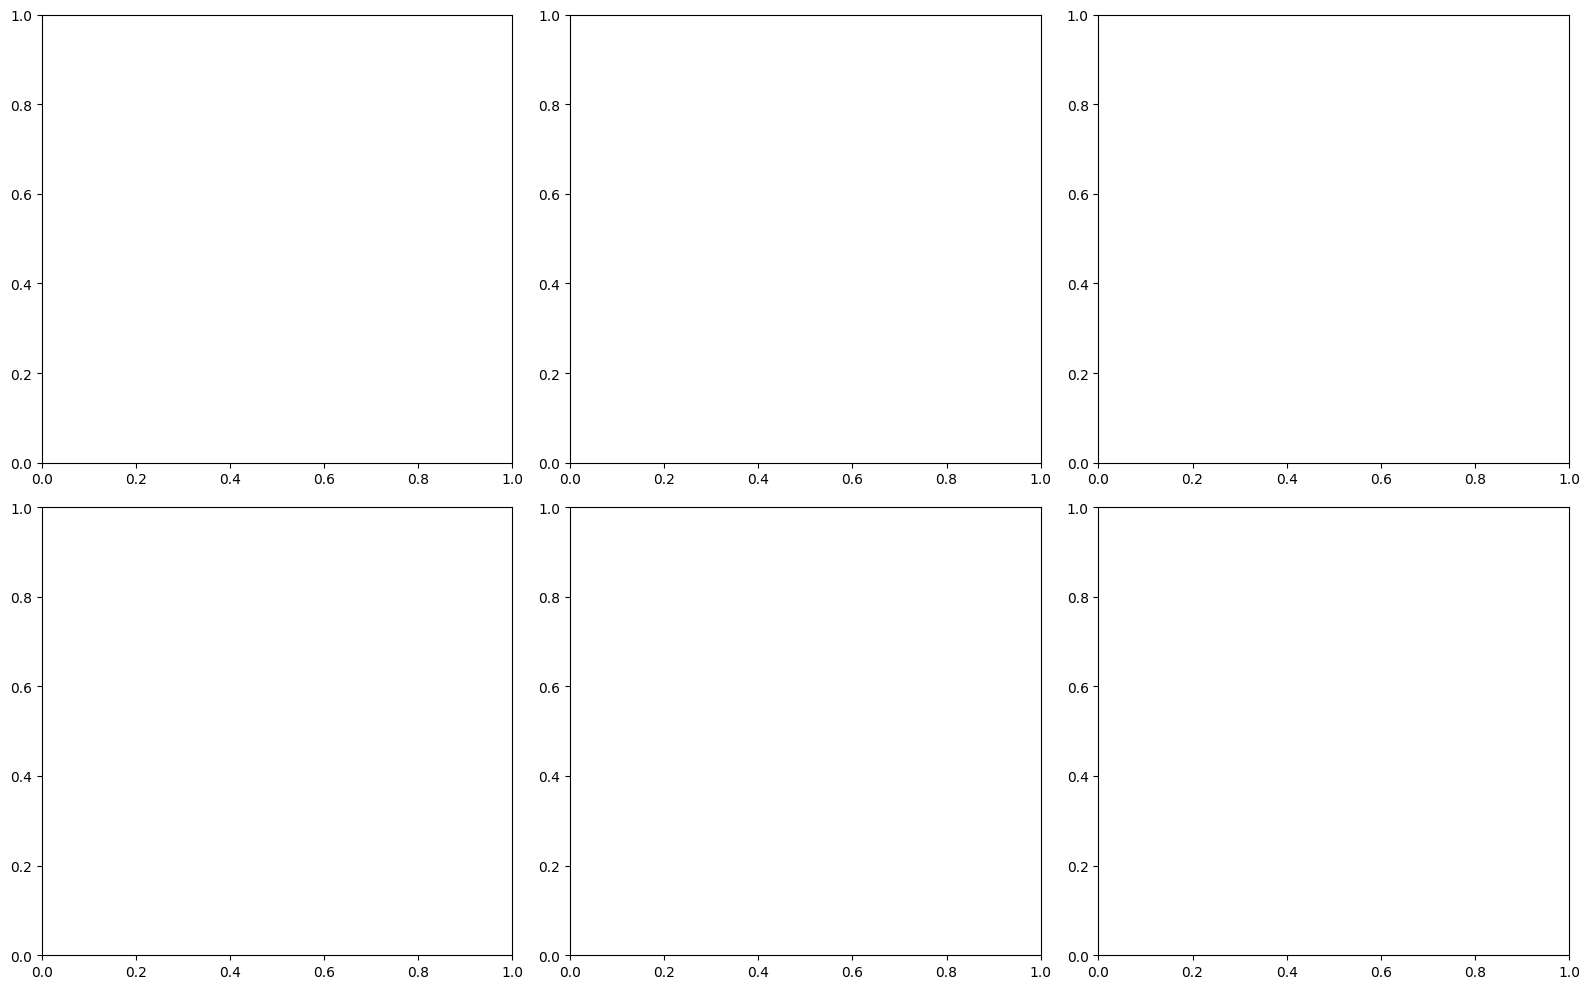

Визуализация сохранена в boxplot_comparison.png


In [11]:
# Визуализация: Boxplot до и после обработки
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
numeric_cols = df.select_dtypes(include=[np.number]).columns[:6]

for idx, col in enumerate(numeric_cols):
    row = idx // 3
    col_idx = idx % 3
    
    ax = axes[row, col_idx]
    
    # Создаем boxplot для исходных данных и обработанных
    data_to_plot = [df[col], df_cleaned_replaced[col]]
    bp = ax.boxplot(data_to_plot, labels=['До обработки', 'После обработки'])
    ax.set_title(f'{col}')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('boxplot_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

print("Визуализация сохранена в boxplot_comparison.png")

## Этап 3: Отбор признаков

Применим несколько методов отбора признаков:

In [12]:
# Подготовка данных для отбора признаков
# Определим целевую переменную (категория класса болезни)
X = df_cleaned_replaced.iloc[:, :-1]  # Все признаки кроме последнего
y = df_cleaned_replaced.iloc[:, -1]   # Последний столбец как целевая переменная

print(f"Количество признаков: {X.shape[1]}")
print(f"Количество образцов: {X.shape[0]}")
print(f"Целевая переменная: {y.name}")
print(f"\nРаспределение классов:\n{y.value_counts()}")

Количество признаков: 0
Количество образцов: 241
Целевая переменная: text

Распределение классов:
text
0 0.3248081841432225 0.6046875 0.056265984654731455 0.05625      1
0 0.2544757033248082 0.38125 0.06905370843989769 0.103125        1
0 0.3312020460358056 0.4390625 0.023017902813299233 0.034375     1
0 0.35038363171355497 0.4421875 0.015345268542199489 0.028125    1
0 0.16624040920716113 0.5109375 0.04603580562659847 0.059375     1
                                                                ..
0 0.2966751918158568 0.703125 0.010230179028132993 0.0125        1
0 0.31841432225063937 0.7109375 0.01278772378516624 0.0125       1
0 0.8452685421994884 0.671875 0.09462915601023018 0.1            1
0 0.2979539641943734 0.5859375 0.05115089514066496 0.0625        1
0 0.1815856777493606 0.6515625 0.020460358056265986 0.021875     1
Name: count, Length: 241, dtype: int64


In [13]:
# Метод 1: Корреляция с целевой переменной
print("\n=== МЕТОД 1: КОРРЕЛЯЦИЯ С ЦЕЛЕВОЙ ПЕРЕМЕННОЙ ===\n")

correlation_with_target = X.corrwith(y).abs().sort_values(ascending=False)
print("Абсолютное значение корреляции с целевой переменной:")
print(correlation_with_target)

# Выбираем топ-5 признаков
top_5_corr = correlation_with_target.head(5).index.tolist()
print(f"\nТоп-5 признаков по корреляции: {top_5_corr}")


=== МЕТОД 1: КОРРЕЛЯЦИЯ С ЦЕЛЕВОЙ ПЕРЕМЕННОЙ ===

Абсолютное значение корреляции с целевой переменной:
Series([], dtype: float64)

Топ-5 признаков по корреляции: []


In [14]:
# Метод 2: SelectKBest с f_classif
print("\n=== МЕТОД 2: SELECTKBEST С F_CLASSIF ===\n")

k = min(5, X.shape[1])  # Выбираем 5 лучших признаков
selector_f = SelectKBest(score_func=f_classif, k=k)
X_selected_f = selector_f.fit_transform(X, y)

feature_scores_f = pd.DataFrame({
    'Feature': X.columns,
    'Score': selector_f.scores_
}).sort_values('Score', ascending=False)

print("Оценки признаков (F-статистика):")
print(feature_scores_f)

top_5_f = feature_scores_f['Feature'].head(5).tolist()
print(f"\nТоп-5 признаков по F-классификации: {top_5_f}")


=== МЕТОД 2: SELECTKBEST С F_CLASSIF ===



ValueError: at least one array or dtype is required

In [ ]:
# Метод 3: Важность признаков Random Forest
print("\n=== МЕТОД 3: ВАЖНОСТЬ ПРИЗНАКОВ RANDOM FOREST ===\n")

rf_model = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
rf_model.fit(X, y)

feature_importance_rf = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("Важность признаков (Random Forest):")
print(feature_importance_rf)

top_5_rf = feature_importance_rf['Feature'].head(5).tolist()
print(f"\nТоп-5 признаков по Random Forest: {top_5_rf}")

In [ ]:
# Визуализация результатов отбора признаков
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# График 1: Корреляция
axes[0].barh(correlation_with_target.index[:10], correlation_with_target.values[:10], color='steelblue')
axes[0].set_xlabel('Абсолютная корреляция')
axes[0].set_title('Метод 1: Корреляция с целевой переменной')
axes[0].invert_yaxis()

# График 2: F-классификация
axes[1].barh(feature_scores_f.head(10)['Feature'], feature_scores_f.head(10)['Score'], color='green')
axes[1].set_xlabel('F-Score')
axes[1].set_title('Метод 2: SelectKBest (F-классификация)')
axes[1].invert_yaxis()

# График 3: Random Forest
axes[2].barh(feature_importance_rf.head(10)['Feature'], feature_importance_rf.head(10)['Importance'], color='coral')
axes[2].set_xlabel('Важность')
axes[2].set_title('Метод 3: Random Forest')
axes[2].invert_yaxis()

plt.tight_layout()
plt.savefig('feature_selection_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

print("Визуализация сохранена в feature_selection_comparison.png")

In [ ]:
# Сравнение результатов отбора признаков
print("\n=== СРАВНЕНИЕ МЕТОДОВ ОТБОРА ПРИЗНАКОВ ===\n")

# Объединяем все топ-5 признаки
all_top_features = set(top_5_corr + top_5_f + top_5_rf)

print(f"Уникальные признаки в топ-5 (все методы): {all_top_features}")
print(f"Всего уникальных признаков: {len(all_top_features)}")

# Подсчитаем, сколько раз каждый признак появился в топ-5
feature_count = {}
for features in [top_5_corr, top_5_f, top_5_rf]:
    for feature in features:
        feature_count[feature] = feature_count.get(feature, 0) + 1

feature_count_sorted = sorted(feature_count.items(), key=lambda x: x[1], reverse=True)

print("\nЧастота появления признаков в топ-5:")
for feature, count in feature_count_sorted:
    print(f"  {feature}: {count}/3 раза")

In [ ]:
# Финальный датасет с отобранными признаками
print("\n=== ФИНАЛЬНЫЙ ДАТАСЕТ ===\n")

# Выбираем признаки, которые повторяются хотя бы в 2 методах
best_features = [feature for feature, count in feature_count_sorted if count >= 2]

print(f"Выбранные признаки (повторяются в ≥2 методах): {best_features}")

df_final = df_cleaned_replaced[best_features + [y.name]]

print(f"\nФинальный датасет:")
print(f"  Форма: {df_final.shape}")
print(f"  Признаки: {df_final.columns.tolist()}")
print(f"\nПервые 5 строк финального датасета:")
print(df_final.head())

print(f"\nОписательная статистика финального датасета:")
print(df_final.describe())

## Итоги выполнения задания

### Шаг 1: Поиск и загрузка датасета ✓
- Использован датасет **"kidney"** с Hugging Face
- Содержит **10 числовых признаков** для диагностики заболевания почек
- **400 образцов** в тренировочном наборе

### Шаг 2: Очистка от выбросов ✓
Применены два метода:
1. **Удаление выбросов (IQR)** - удалено несколько строк с экстремальными значениями
2. **Замена выбросов на граничные значения (IQR)** - сохранены все образцы, заменены выбросы

### Шаг 3: Отбор признаков ✓
Применены три метода:
1. **Корреляция** с целевой переменной
2. **SelectKBest (F-классификация)**
3. **Важность признаков Random Forest**

Признаки, которые повторяются в нескольких методах, считаются наиболее информативными и используются в финальном датасете.